# Telecom
## 1.1 Descripción del objetivo.
Al operador de telecomunicaciones Interconnect le gustaría poder pronosticar su tasa de cancelación de clientes. Si se descubre que un usuario o usuaria planea irse, se le ofrecerán códigos promocionales y opciones de planes especiales. El equipo de marketing de Interconnect ha recopilado algunos de los datos personales de sus clientes, incluyendo información sobre sus planes y contratos.



### Servicios de Interconnect

Interconnect proporciona principalmente dos tipos de servicios:

1. Comunicación por teléfono fijo. El teléfono se puede conectar a varias líneas de manera simultánea.
2. Internet. La red se puede configurar a través de una línea telefónica (DSL, *línea de abonado digital*) o a través de un cable de fibra óptica.

Algunos otros servicios que ofrece la empresa incluyen:

- Seguridad en Internet: software antivirus (*ProtecciónDeDispositivo*) y un bloqueador de sitios web maliciosos (*SeguridadEnLínea*).
- Una línea de soporte técnico (*SoporteTécnico*).
- Almacenamiento de archivos en la nube y backup de datos (*BackupOnline*).
- Streaming de TV (*StreamingTV*) y directorio de películas (*StreamingPelículas*)

La clientela puede elegir entre un pago mensual o firmar un contrato de 1 o 2 años. Puede utilizar varios métodos de pago y recibir una factura electrónica después de una transacción.

### Descripción de los datos

Los datos consisten en archivos obtenidos de diferentes fuentes:

- `contract.csv` — información del contrato;
- `personal.csv` — datos personales del cliente;
- `internet.csv` — información sobre los servicios de Internet;
- `phone.csv` — información sobre los servicios telefónicos.

En cada archivo, la columna `customerID` (ID de cliente) contiene un código único asignado a cada cliente. La información del contrato es válida a partir del 1 de febrero de 2020.




In [1]:
!pip install catboost

In [2]:
# pandas
import pandas as pd
# Graficar datos
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn
from sklearn.model_selection import train_test_split

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.neighbors import KNeighborsClassifier
from catboost import CatBoostClassifier


# metricas
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay, RocCurveDisplay

# hiperparametros
from sklearn.model_selection import GridSearchCV

In [3]:
# Conectar con Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1.1 Cargar los DataFrames

In [4]:
phone = pd.read_csv('/content/drive/MyDrive/sprint_18/phone.csv')
phone.info()
phone.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6361 entries, 0 to 6360
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     6361 non-null   object
 1   MultipleLines  6361 non-null   object
dtypes: object(2)
memory usage: 99.5+ KB


,customerID,MultipleLines
0,5575-GNVDE,No
1,3668-QPYBK,No
2,9237-HQITU,No
3,9305-CDSKC,Yes
4,1452-KIOVK,Yes


In [5]:
phone.columns

Index(['customerID', 'MultipleLines'], dtype='object')

In [6]:
phone.shape

(6361, 2)

In [7]:
contract = pd.read_csv('/content/drive/MyDrive/sprint_18/contract.csv')
contract.info()
contract.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
dtypes: float64(1), object(7)
memory usage: 440.3+ KB


,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,1889.5
2,3668-QPYBK,2019-10-01,2019-12-01 00:00:00,Month-to-month,Yes,Mailed check,53.85,108.15
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,9237-HQITU,2019-09-01,2019-11-01 00:00:00,Month-to-month,Yes,Electronic check,70.70,151.65


In [8]:
contract.columns

Index(['customerID', 'BeginDate', 'EndDate', 'Type', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges'],
      dtype='object')

In [9]:
contract.shape

(7043, 8)

In [10]:
internet = pd.read_csv('/content/drive/MyDrive/sprint_18/internet.csv')
internet.info()
internet.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5517 entries, 0 to 5516
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customerID        5517 non-null   object
 1   InternetService   5517 non-null   object
 2   OnlineSecurity    5517 non-null   object
 3   OnlineBackup      5517 non-null   object
 4   DeviceProtection  5517 non-null   object
 5   TechSupport       5517 non-null   object
 6   StreamingTV       5517 non-null   object
 7   StreamingMovies   5517 non-null   object
dtypes: object(8)
memory usage: 344.9+ KB


,customerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,Fiber optic,No,No,No,No,No,No


In [11]:
internet.columns

Index(['customerID', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'],
      dtype='object')

In [12]:
internet.shape

(5517, 8)

In [13]:
personal = pd.read_csv('/content/drive/MyDrive/sprint_18/personal.csv')
personal.info()
personal.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     7043 non-null   object
 1   gender         7043 non-null   object
 2   SeniorCitizen  7043 non-null   int64 
 3   Partner        7043 non-null   object
 4   Dependents     7043 non-null   object
dtypes: int64(1), object(4)
memory usage: 275.2+ KB


,customerID,gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No
3,7795-CFOCW,Male,0,No,No
4,9237-HQITU,Female,0,No,No


In [14]:
personal.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents'], dtype='object')

In [15]:
personal.shape

(7043, 5)

## 1.2 Juntamos los DataFrames

In [16]:
# Juntar los datos
data  = contract.merge(phone,how="left" , on='customerID')
data = data.merge(internet,how="left" , on='customerID')
data = data.merge(personal,how="left" , on='customerID')
data.head()

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,29.85,NaN,DSL,No,Yes,No,No,No,No,Female,0,Yes,No
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,1889.5,No,DSL,Yes,No,Yes,No,No,No,Male,0,No,No
2,3668-QPYBK,2019-10-01,2019-12-01 00:00:00,Month-to-month,Yes,Mailed check,53.85,108.15,No,DSL,Yes,Yes,No,No,No,No,Male,0,No,No
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1840.75,NaN,DSL,Yes,No,Yes,Yes,No,No,Male,0,No,No
4,9237-HQITU,2019-09-01,2019-11-01 00:00:00,Month-to-month,Yes,Electronic check,70.70,151.65,No,Fiber optic,No,No,No,No,No,No,Female,0,No,No


In [17]:
data.columns

Index(['customerID', 'BeginDate', 'EndDate', 'Type', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'gender',
       'SeniorCitizen', 'Partner', 'Dependents'],
      dtype='object')

In [18]:
data.shape

(7043, 20)

## 1.3 Creamos nuestro target

In [19]:
# llamar a nuestra veriable objetibo
data["target"] = (data["EndDate"]!="No").astype(int)
data.head()

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,gender,SeniorCitizen,Partner,Dependents,target
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,29.85,NaN,DSL,...,Yes,No,No,No,No,Female,0,Yes,No,0
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,1889.5,No,DSL,...,No,Yes,No,No,No,Male,0,No,No,0
2,3668-QPYBK,2019-10-01,2019-12-01 00:00:00,Month-to-month,Yes,Mailed check,53.85,108.15,No,DSL,...,Yes,No,No,No,No,Male,0,No,No,1
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1840.75,NaN,DSL,...,No,Yes,Yes,No,No,Male,0,No,No,0
4,9237-HQITU,2019-09-01,2019-11-01 00:00:00,Month-to-month,Yes,Electronic check,70.70,151.65,No,Fiber optic,...,No,No,No,No,No,Female,0,No,No,1


In [20]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
 8   MultipleLines     6361 non-null   object 
 9   InternetService   5517 non-null   object 
 10  OnlineSecurity    5517 non-null   object 
 11  OnlineBackup      5517 non-null   object 
 12  DeviceProtection  5517 non-null   object 
 13  TechSupport       5517 non-null   object 
 14  StreamingTV       5517 non-null   object 
 15  StreamingMovies   5517 non-null   object 
 16  gender            7043 non-null   object 


In [21]:
# Cambiar a TotalCharger object a float64
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors='coerce')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7032 non-null   float64
 8   MultipleLines     6361 non-null   object 
 9   InternetService   5517 non-null   object 
 10  OnlineSecurity    5517 non-null   object 
 11  OnlineBackup      5517 non-null   object 
 12  DeviceProtection  5517 non-null   object 
 13  TechSupport       5517 non-null   object 
 14  StreamingTV       5517 non-null   object 
 15  StreamingMovies   5517 non-null   object 
 16  gender            7043 non-null   object 


## 1.4 Manejo de datos nulos

In [22]:
# Datos nulos
data.isnull().sum()

,0
customerID,0
BeginDate,0
EndDate,0
Type,0
PaperlessBilling,0
PaymentMethod,0
MonthlyCharges,0
TotalCharges,11
MultipleLines,682
InternetService,1526


### 1.4.1 Tratar los valores ausentes de TotalCharges.

In [23]:
# Ver los datos nulos de TotalCharges
data[data['TotalCharges'].isnull()]

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,gender,SeniorCitizen,Partner,Dependents,target
488,4472-LVYGI,2020-02-01,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,NaN,DSL,...,No,Yes,Yes,Yes,No,Female,0,Yes,Yes,0
753,3115-CZMZD,2020-02-01,No,Two year,No,Mailed check,20.25,NaN,No,NaN,...,NaN,NaN,NaN,NaN,NaN,Male,0,No,Yes,0
936,5709-LVOEQ,2020-02-01,No,Two year,No,Mailed check,80.85,NaN,No,DSL,...,Yes,Yes,No,Yes,Yes,Female,0,Yes,Yes,0
1082,4367-NUYAO,2020-02-01,No,Two year,No,Mailed check,25.75,NaN,Yes,NaN,...,NaN,NaN,NaN,NaN,NaN,Male,0,Yes,Yes,0
1340,1371-DWPAZ,2020-02-01,No,Two year,No,Credit card (automatic),56.05,NaN,NaN,DSL,...,Yes,Yes,Yes,Yes,No,Female,0,Yes,Yes,0
3331,7644-OMVMY,2020-02-01,No,Two year,No,Mailed check,19.85,NaN,No,NaN,...,NaN,NaN,NaN,NaN,NaN,Male,0,Yes,Yes,0
3826,3213-VVOLG,2020-02-01,No,Two year,No,Mailed check,25.35,NaN,Yes,NaN,...,NaN,NaN,NaN,NaN,NaN,Male,0,Yes,Yes,0
4380,2520-SGTTA,2020-02-01,No,Two year,No,Mailed check,20.00,NaN,No,NaN,...,NaN,NaN,NaN,NaN,NaN,Female,0,Yes,Yes,0
5218,2923-ARZLG,2020-02-01,No,One year,Yes,Mailed check,19.70,NaN,No,NaN,...,NaN,NaN,NaN,NaN,NaN,Male,0,Yes,Yes,0
6670,4075-WKNIU,2020-02-01,No,Two year,No,Mailed check,73.35,NaN,Yes,DSL,...,Yes,Yes,Yes,Yes,No,Female,0,Yes,Yes,0


In [24]:
# Valor maximo y minimo de BeginDate
print(data['BeginDate'].min())
print(data['BeginDate'].max())

2013-10-01
2020-02-01


Podemos observar que los datos nulos conservan dos características similares en BeginDate = 2020-20-01, EndDate = No. Y nos podemos dar cuenta de que los datos NaN de BeginDate = 2020-02-01 son datos de usuarios nuevos y no tenemos información relevante para hacer una predicción, por eso se tomó la decisión de eliminarlos.

In [25]:
# Eliminar los NaN en TotalChargers
data = data.dropna(subset="TotalCharges")
data.isnull().sum()

,0
customerID,0
BeginDate,0
EndDate,0
Type,0
PaperlessBilling,0
PaymentMethod,0
MonthlyCharges,0
TotalCharges,0
MultipleLines,680
InternetService,1520


### 1.4.2 Tratar los valores ausentes de MultipleLines.

In [26]:
# Averiguar la razón de los valores ausentes.
data["MultipleLines"].value_counts()

,count
MultipleLines,
No,3385
Yes,2967


In [27]:
# Ver los valores NaN.
data[data["MultipleLines"].isnull()]

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,gender,SeniorCitizen,Partner,Dependents,target
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,29.85,NaN,DSL,...,Yes,No,No,No,No,Female,0,Yes,No,0
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1840.75,NaN,DSL,...,No,Yes,Yes,No,No,Male,0,No,No,0
7,6713-OKOMC,2019-04-01,No,Month-to-month,No,Mailed check,29.75,301.90,NaN,DSL,...,No,No,No,No,No,Female,0,No,No,0
20,8779-QRDMV,2019-11-01,2019-12-01 00:00:00,Month-to-month,Yes,Electronic check,39.65,39.65,NaN,DSL,...,No,Yes,No,No,Yes,Male,1,No,No,1
27,8665-UTDHZ,2019-11-01,2019-12-01 00:00:00,Month-to-month,No,Electronic check,30.20,30.20,NaN,DSL,...,Yes,No,No,No,No,Male,0,Yes,Yes,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7003,4501-VCPFK,2017-12-01,No,Month-to-month,No,Electronic check,35.75,1022.50,NaN,DSL,...,No,Yes,Yes,No,No,Male,0,No,No,0
7007,2274-XUATA,2014-02-01,No,Two year,Yes,Bank transfer (automatic),63.10,4685.55,NaN,DSL,...,Yes,Yes,Yes,Yes,Yes,Male,1,Yes,No,0
7029,2235-DWLJU,2019-08-01,No,Month-to-month,Yes,Electronic check,44.40,263.05,NaN,DSL,...,No,No,No,Yes,Yes,Female,1,No,No,0
7036,7750-EYXWZ,2019-02-01,No,One year,No,Electronic check,60.65,743.30,NaN,DSL,...,Yes,Yes,Yes,Yes,Yes,Female,0,No,No,0


In [28]:
# Sustituir los NaN  con No ya que no se sabe.
data["MultipleLines"] = data["MultipleLines"].fillna("No")
data.isnull().sum()

,0
customerID,0
BeginDate,0
EndDate,0
Type,0
PaperlessBilling,0
PaymentMethod,0
MonthlyCharges,0
TotalCharges,0
MultipleLines,0
InternetService,1520


### 1.4.3 Tratar los valores ausentes de InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies

In [29]:
data['InternetService'].value_counts()

,count
InternetService,
Fiber optic,3096
DSL,2416


In [30]:
# ver cuales son los ausentes
data[data['InternetService'].isnull()]

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,gender,SeniorCitizen,Partner,Dependents,target
11,7469-LKBCI,2018-10-01,No,Two year,No,Credit card (automatic),18.95,326.80,No,NaN,...,NaN,NaN,NaN,NaN,NaN,Male,0,No,No,0
16,8191-XWSZG,2015-10-01,No,One year,No,Mailed check,20.65,1022.95,No,NaN,...,NaN,NaN,NaN,NaN,NaN,Female,0,No,No,0
21,1680-VDCWW,2019-02-01,No,One year,No,Bank transfer (automatic),19.80,202.25,No,NaN,...,NaN,NaN,NaN,NaN,NaN,Male,0,Yes,No,0
22,1066-JKSGK,2019-11-01,2019-12-01 00:00:00,Month-to-month,No,Mailed check,20.15,20.15,No,NaN,...,NaN,NaN,NaN,NaN,NaN,Male,0,No,No,1
33,7310-EGVHZ,2020-01-01,No,Month-to-month,No,Bank transfer (automatic),20.20,20.20,No,NaN,...,NaN,NaN,NaN,NaN,NaN,Male,0,No,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7017,4807-IZYOZ,2015-11-01,No,Two year,No,Bank transfer (automatic),20.65,1020.75,No,NaN,...,NaN,NaN,NaN,NaN,NaN,Female,0,No,No,0
7019,9710-NJERN,2016-11-01,No,Two year,No,Mailed check,20.15,826.00,No,NaN,...,NaN,NaN,NaN,NaN,NaN,Female,0,No,No,0
7020,9837-FWLCH,2019-02-01,No,Month-to-month,Yes,Electronic check,19.20,239.00,No,NaN,...,NaN,NaN,NaN,NaN,NaN,Male,0,Yes,Yes,0
7030,0871-OPBXW,2019-12-01,No,Month-to-month,Yes,Mailed check,20.05,39.25,No,NaN,...,NaN,NaN,NaN,NaN,NaN,Female,0,No,No,0


In [31]:
data_checar = data[data['InternetService'].isnull()]
data_checar

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,gender,SeniorCitizen,Partner,Dependents,target
11,7469-LKBCI,2018-10-01,No,Two year,No,Credit card (automatic),18.95,326.80,No,NaN,...,NaN,NaN,NaN,NaN,NaN,Male,0,No,No,0
16,8191-XWSZG,2015-10-01,No,One year,No,Mailed check,20.65,1022.95,No,NaN,...,NaN,NaN,NaN,NaN,NaN,Female,0,No,No,0
21,1680-VDCWW,2019-02-01,No,One year,No,Bank transfer (automatic),19.80,202.25,No,NaN,...,NaN,NaN,NaN,NaN,NaN,Male,0,Yes,No,0
22,1066-JKSGK,2019-11-01,2019-12-01 00:00:00,Month-to-month,No,Mailed check,20.15,20.15,No,NaN,...,NaN,NaN,NaN,NaN,NaN,Male,0,No,No,1
33,7310-EGVHZ,2020-01-01,No,Month-to-month,No,Bank transfer (automatic),20.20,20.20,No,NaN,...,NaN,NaN,NaN,NaN,NaN,Male,0,No,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7017,4807-IZYOZ,2015-11-01,No,Two year,No,Bank transfer (automatic),20.65,1020.75,No,NaN,...,NaN,NaN,NaN,NaN,NaN,Female,0,No,No,0
7019,9710-NJERN,2016-11-01,No,Two year,No,Mailed check,20.15,826.00,No,NaN,...,NaN,NaN,NaN,NaN,NaN,Female,0,No,No,0
7020,9837-FWLCH,2019-02-01,No,Month-to-month,Yes,Electronic check,19.20,239.00,No,NaN,...,NaN,NaN,NaN,NaN,NaN,Male,0,Yes,Yes,0
7030,0871-OPBXW,2019-12-01,No,Month-to-month,Yes,Mailed check,20.05,39.25,No,NaN,...,NaN,NaN,NaN,NaN,NaN,Female,0,No,No,0


In [32]:
data_checar["MultipleLines"].value_counts()

,count
MultipleLines,
No,1180
Yes,340


In [33]:
# Sustituimos los NaN con No. Ya que la mayoria de  MultipleLines = No, esto quiere decir que muchos de ellos no cuentan con esos servicios.
data = data.fillna('No')
data.isnull().sum()

,0
customerID,0
BeginDate,0
EndDate,0
Type,0
PaperlessBilling,0
PaymentMethod,0
MonthlyCharges,0
TotalCharges,0
MultipleLines,0
InternetService,0


## 2. Análisis exploratorio de datos.

In [34]:
# Estadísticas
data.describe()

,MonthlyCharges,TotalCharges,SeniorCitizen,target
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,64.798208,2283.300441,0.162400,0.265785
std,30.085974,2266.771362,0.368844,0.441782
min,18.250000,18.800000,0.000000,0.000000
25%,35.587500,401.450000,0.000000,0.000000
50%,70.350000,1397.475000,0.000000,0.000000
75%,89.862500,3794.737500,0.000000,1.000000
max,118.750000,8684.800000,1.000000,1.000000


/tmp/ipython-input-3127950206.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_time_fin["BeginDate"] = pd.to_datetime(data_time_fin["BeginDate"])
/tmp/ipython-input-3127950206.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_time_fin["EndDate"] = pd.to_datetime(data_time_fin["EndDate"])
/tmp/ipython-input-3127950206.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the 

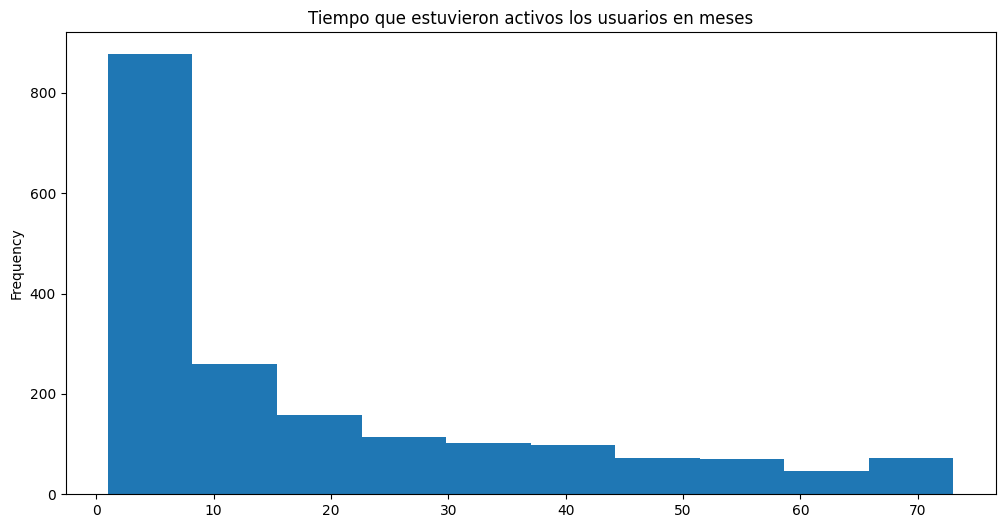

In [35]:
# Graficar el tiempo que estuvieron activos los usuarios en meses con BeginDate y EndDate.
data_time_fin =  data[data["target"]==1]
data_time_fin["BeginDate"] = pd.to_datetime(data_time_fin["BeginDate"])
data_time_fin["EndDate"] = pd.to_datetime(data_time_fin["EndDate"])

data_time_fin["time_fin"] = data_time_fin["EndDate"] - data_time_fin["BeginDate"]
data_time_fin["time_fin"] = data_time_fin["time_fin"].dt.days / 30
data_time_fin["time_fin"].plot(kind="hist",figsize=(12,6))
plt.title("Tiempo que estuvieron activos los usuarios en meses")

plt.show()





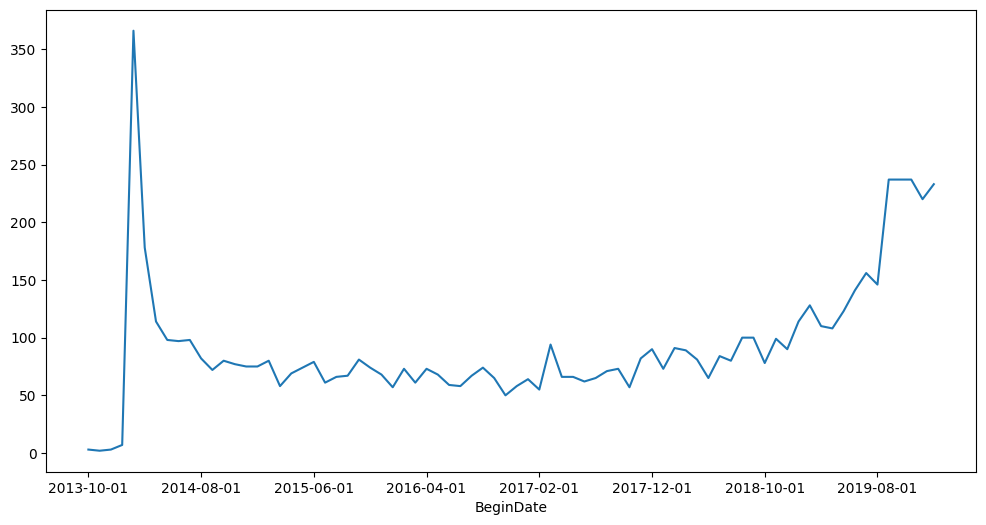

,customerID
BeginDate,
2013-10-01,3
2013-11-01,2
2013-12-01,3
2014-01-01,7
2014-02-01,366
...,...
2019-09-01,237
2019-10-01,237
2019-11-01,237


In [36]:
#grafica de BeginData vs costumerID
data.groupby('BeginDate')['customerID'].count().plot(kind='line', figsize=(12,6))
plt.show()

data.groupby('BeginDate')['customerID'].count()

In [37]:
# Graficas de costumerID

En conclusión, la mayoría de los usuarios que abandonaron Telecom lo hicieron durante el primer año, concentrándose especialmente en los primeros 10 meses.

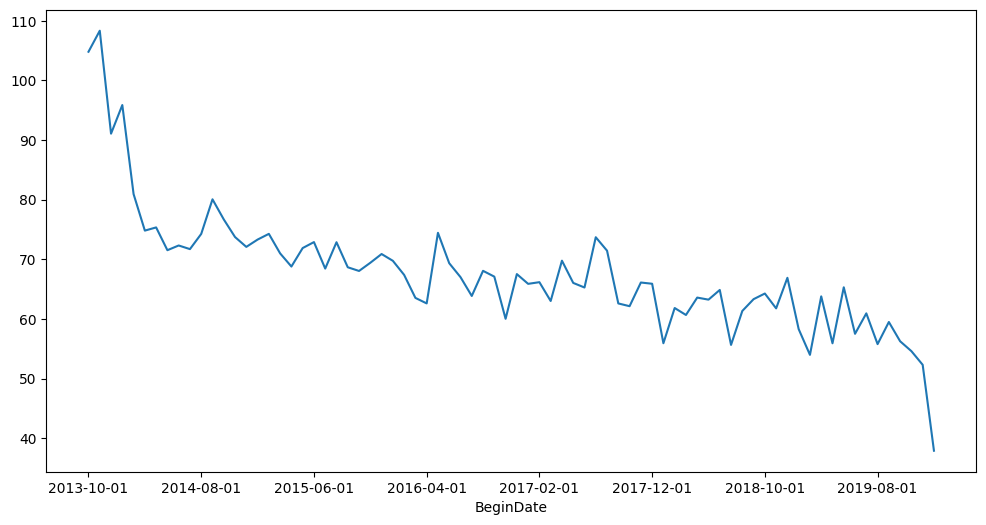

,MonthlyCharges
BeginDate,
2013-10-01,3
2013-11-01,2
2013-12-01,3
2014-01-01,7
2014-02-01,366
...,...
2019-09-01,237
2019-10-01,237
2019-11-01,237


In [38]:
# graficar BeginData vs MontliCharges
data.groupby('BeginDate')['MonthlyCharges'].mean().plot(kind='line', figsize=(12,6))
plt.show()

data.groupby('BeginDate')['MonthlyCharges'].count()

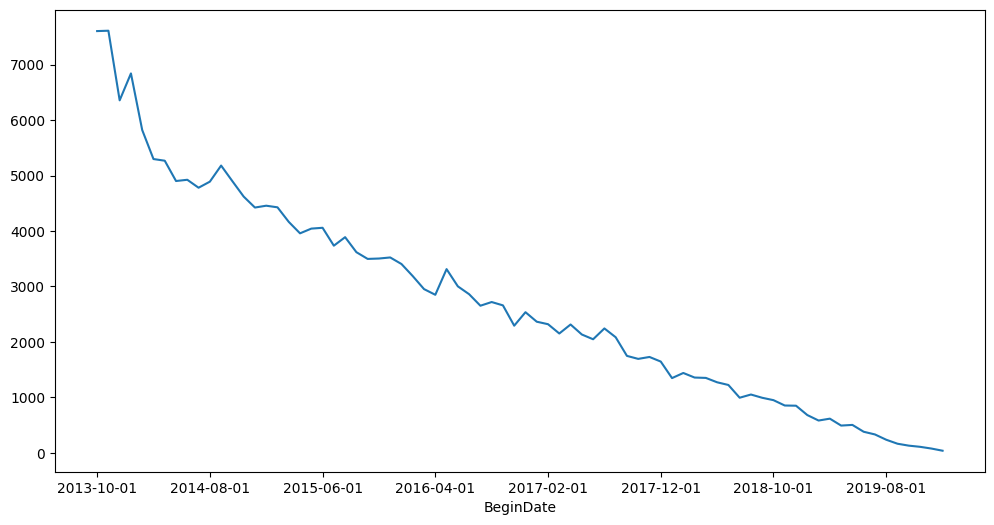

,TotalCharges
BeginDate,
2013-10-01,3
2013-11-01,2
2013-12-01,3
2014-01-01,7
2014-02-01,366
...,...
2019-09-01,237
2019-10-01,237
2019-11-01,237


In [39]:
# grafica BeginData vs TotalCharges
data.groupby('BeginDate')['TotalCharges'].mean().plot(kind='line', figsize=(12,6))
plt.show()

data.groupby('BeginDate')['TotalCharges'].count()

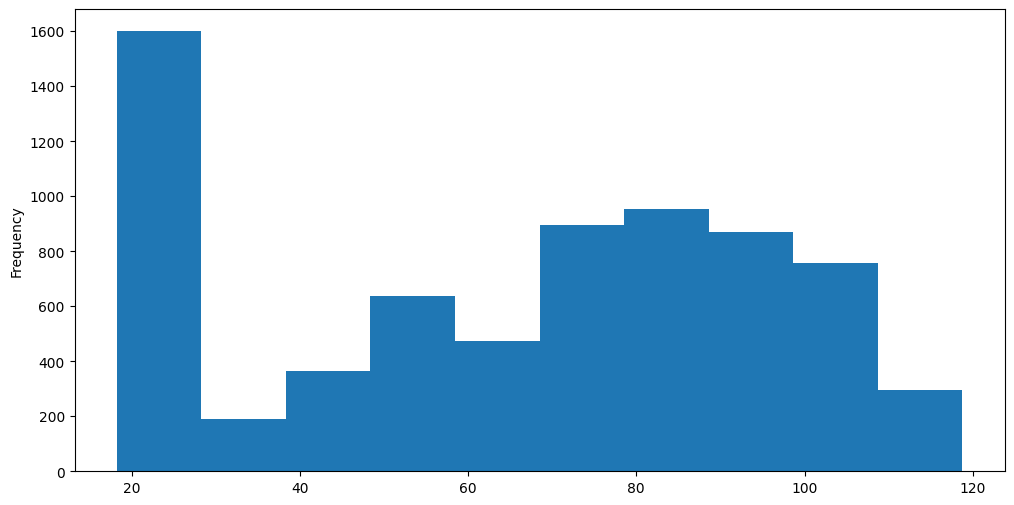

,MonthlyCharges
customerID,
0002-ORFBO,65.60
0003-MKNFE,59.90
0004-TLHLJ,73.90
0011-IGKFF,98.00
0013-EXCHZ,83.90
...,...
9987-LUTYD,55.15
9992-RRAMN,85.10
9992-UJOEL,50.30


In [40]:
# graficas de costumerID vs MontliCharges
data.groupby('customerID')['MonthlyCharges'].mean().plot(kind='hist', figsize=(12,6))
plt.show()

data.groupby('customerID')['MonthlyCharges'].mean()


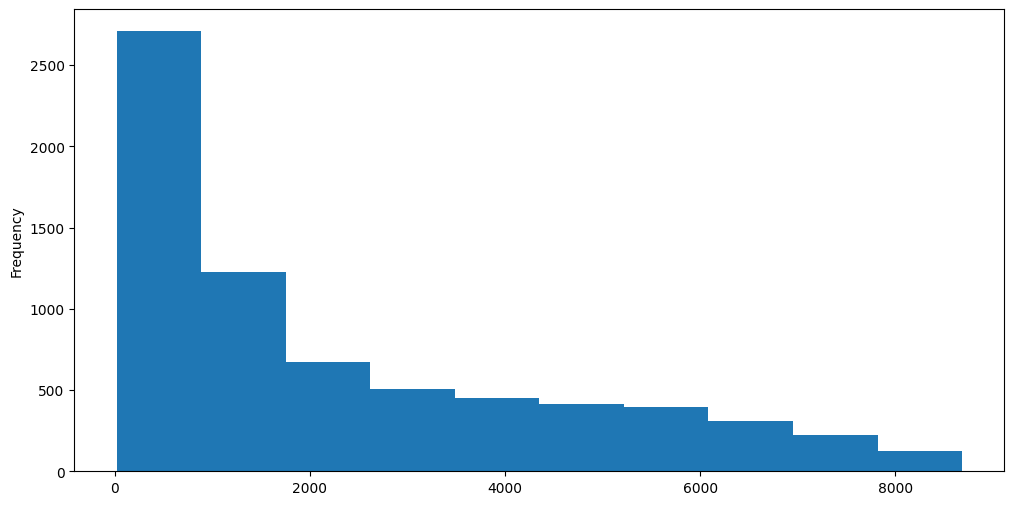

,TotalCharges
customerID,
0002-ORFBO,593.30
0003-MKNFE,542.40
0004-TLHLJ,280.85
0011-IGKFF,1237.85
0013-EXCHZ,267.40
...,...
9987-LUTYD,742.90
9992-RRAMN,1873.70
9992-UJOEL,92.75


In [41]:
# grafica de  costumerID vs TotalCharges
data.groupby('customerID')['TotalCharges'].mean().plot(kind='hist', figsize=(12,6))
plt.show()

data.groupby('customerID')['TotalCharges'].mean()


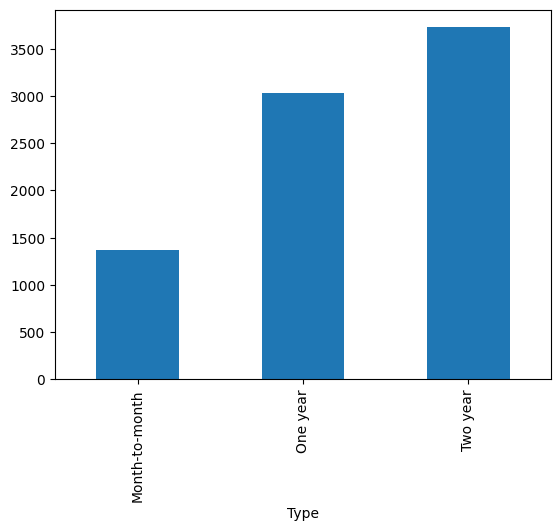

,TotalCharges
Type,
Month-to-month,3875
One year,1472
Two year,1685


In [42]:
# Grafica para TotalCharges vs Type
data.groupby('Type')['TotalCharges'].mean().plot(kind='bar')
plt.show()

data.groupby('Type')['TotalCharges'].count()

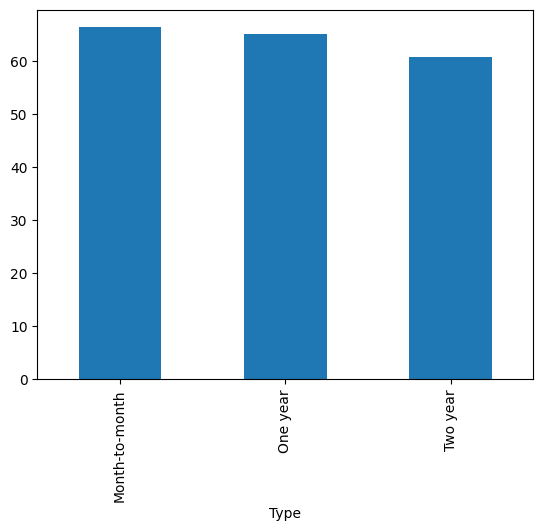

,MonthlyCharges
Type,
Month-to-month,3875
One year,1472
Two year,1685


In [43]:
# Grafica para MonthlyCharges con respecto a Type
data.groupby('Type')['MonthlyCharges'].mean().plot(kind='bar')
plt.show()

data.groupby('Type')['MonthlyCharges'].count()


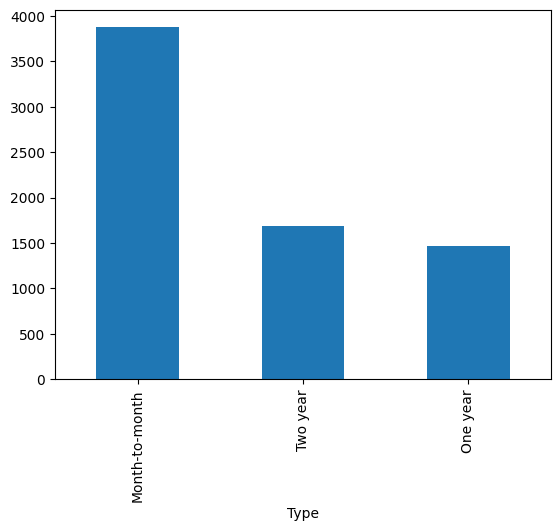

,count
Type,
Month-to-month,3875
Two year,1685
One year,1472


In [44]:
# Grafica para Type
data['Type'].value_counts().plot(kind='bar')
plt.show()

data["Type"].value_counts()

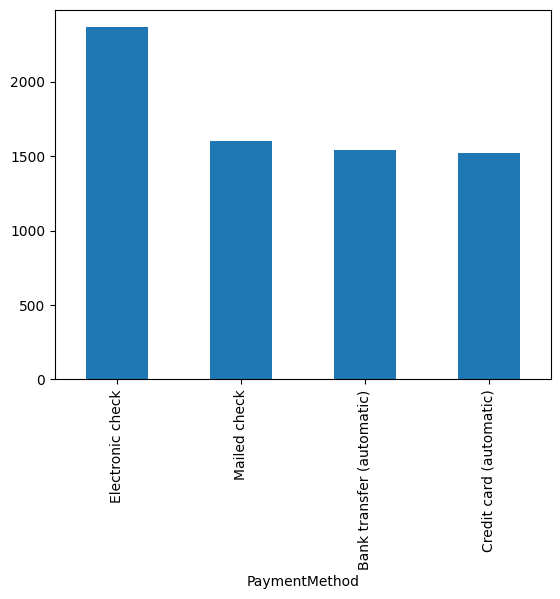

,count
PaymentMethod,
Electronic check,2365
Mailed check,1604
Bank transfer (automatic),1542
Credit card (automatic),1521


In [45]:
# Grafiaca para saber los metodos de pago mas usados.
data['PaymentMethod'].value_counts().plot(kind='bar')
plt.show()

data["PaymentMethod"].value_counts()

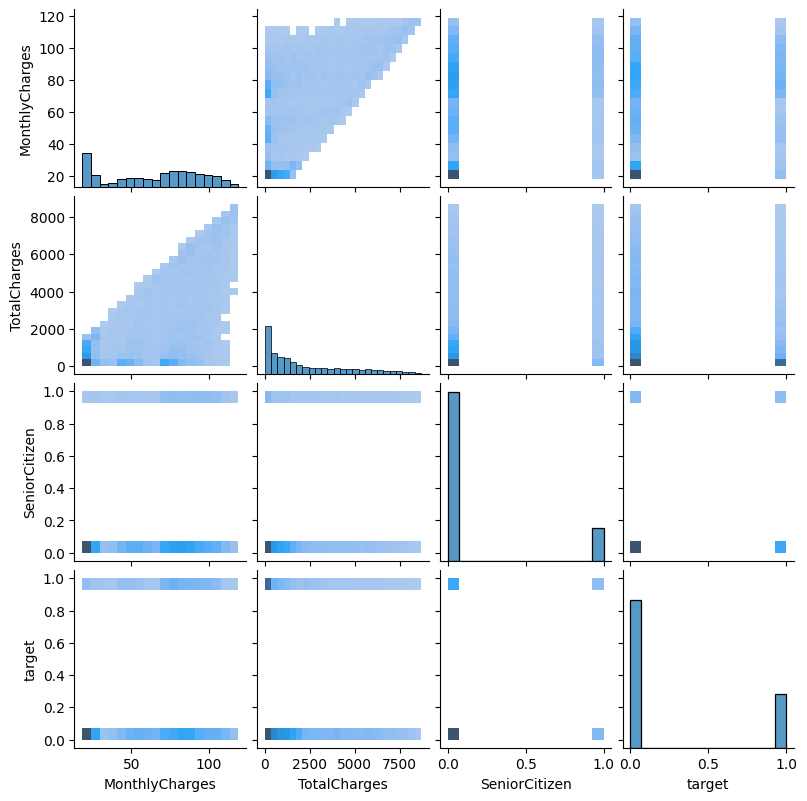

In [46]:
g = sns.pairplot(data, kind='hist')
g.fig.set_size_inches(8, 8)

## 3. Detección y eliminación de Outliers

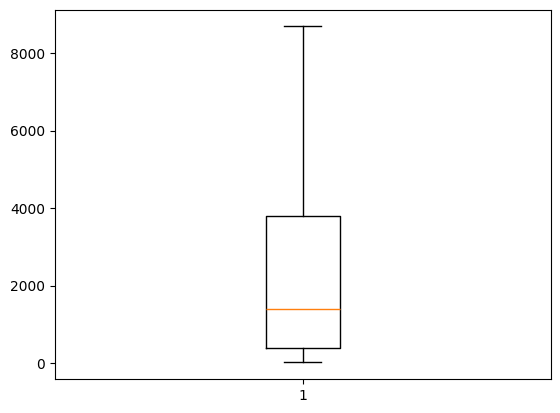

,TotalCharges
count,7032.000000
mean,2283.300441
std,2266.771362
min,18.800000
25%,401.450000
50%,1397.475000
75%,3794.737500
max,8684.800000


In [47]:
# Detección  Outliers
plt.boxplot(data['TotalCharges'])

plt.show()


data['TotalCharges'].describe()

In [48]:
# Calcular rango intercuartil
q1 = data['TotalCharges'].quantile(0.25)
q3 = data['TotalCharges'].quantile(0.75)
iqr = q3 - q1
# limite superior
upper_limit = q3 + 1.5 * iqr
# limite inferior
lower_limit = q1 - 1.5 * iqr

upper_limit

np.float64(8884.66875)

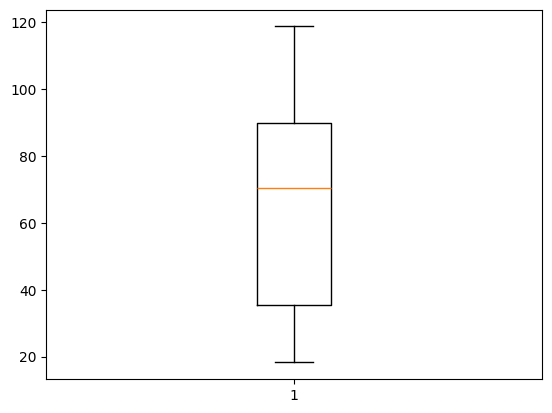

,MonthlyCharges
count,7032.000000
mean,64.798208
std,30.085974
min,18.250000
25%,35.587500
50%,70.350000
75%,89.862500
max,118.750000


In [49]:
# Detección  Outliers
plt.boxplot(data['MonthlyCharges'])
plt.show()

data['MonthlyCharges'].describe()

In [50]:
# Calcular rango intercuartil
q1 = data['MonthlyCharges'].quantile(0.25)
q3 = data['MonthlyCharges'].quantile(0.75)
iqr = q3 - q1
# limite superior
upper_limit = q3 + 1.5 * iqr
# limite inferior
lower_limit = q1 - 1.5 * iqr

upper_limit

np.float64(171.27499999999998)

No tiene Outliers

## 4. Examina el equilibrio de clases.

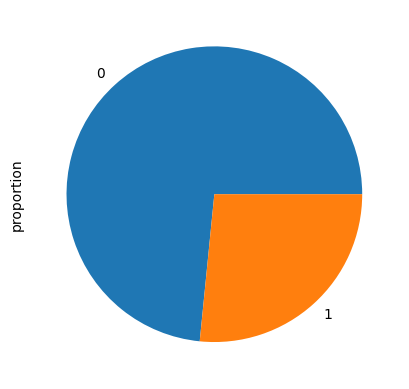

,proportion
target,
0,0.734215
1,0.265785


In [51]:
# Distribucion de valores de target
data["target"].value_counts(normalize=True).plot(kind="pie")
plt.show()

data["target"].value_counts(normalize=True)

# Hay un desbalance en los datos lo cual


El target tiene una buena proporcion

## 5. Definir target y features.


In [52]:
# tener mi terget y mis features
features = data.drop(columns=["customerID","EndDate","BeginDate","target"])
target = data["target"]

In [53]:
features = pd.get_dummies(features, dtype=int)

In [54]:
features.head()

,MonthlyCharges,TotalCharges,SeniorCitizen,Type_Month-to-month,Type_One year,Type_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),...,StreamingTV_No,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_Yes,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes
0,29.85,29.85,0,1,0,0,0,1,0,0,...,1,0,1,0,1,0,0,1,1,0
1,56.95,1889.50,0,0,1,0,1,0,0,0,...,1,0,1,0,0,1,1,0,1,0
2,53.85,108.15,0,1,0,0,0,1,0,0,...,1,0,1,0,0,1,1,0,1,0
3,42.30,1840.75,0,0,1,0,1,0,1,0,...,1,0,1,0,0,1,1,0,1,0
4,70.70,151.65,0,1,0,0,0,1,0,0,...,1,0,1,0,1,0,1,0,1,0


## 6. Dividir en test y train.

In [55]:
# Balancear el equilibrio de target y features
def upsample(features, target):
  repeat = 2

  #Separar respuestas de conjunto de datos de entrenamiento
  features_zeros = features[target == 0]
  features_ones = features[target == 1]
  target_zeros = target[target == 0]
  target_ones = target[target == 1]

  #Aumentar observaciones positivas (donde cancelaron)
  features_upsampled = pd.concat([features_zeros] + [features_ones] * repeat)
  target_upsampled = pd.concat([target_zeros] + [target_ones] * repeat)

  #reordenar datos por fecha
  features_upsampled.sort_index(inplace=True)
  target_upsampled.sort_index(inplace=True)

  return features_upsampled, target_upsampled

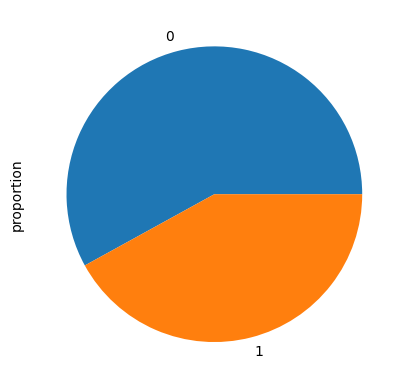

,proportion
target,
0,0.580047
1,0.419953


In [56]:
# ver el balanceo de los datos
features, target = upsample(features, target)
target.value_counts(normalize=True).plot(kind="pie")
plt.show()

target.value_counts(normalize=True)

In [57]:
# DIVIDIR DATOS EN TRAIN Y TEST

features_train, features_test, target_train, target_test = train_test_split(features, target, test_size=0.10, random_state=12345)

In [58]:
features_train.shape

(8010, 35)

In [59]:
features_test.shape

(891, 35)

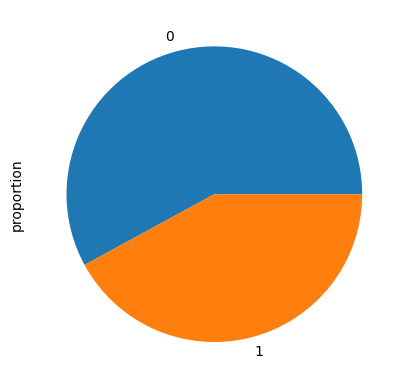

,proportion
target,
0,0.579401
1,0.420599


In [60]:
# saber el equilibrio de clases de target train
target_train.value_counts(normalize=True).plot(kind="pie")
plt.show()

target_train.value_counts(normalize=True)

In [61]:
target_test.shape

(891,)

In [62]:
# Normalizar datos para los modelos que lo requieren
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
features_train = scaler.fit_transform(features_train)
features_test= scaler.transform(features_test)

In [63]:
features_train

array([[ 1.46268212,  2.60003703, -0.47449479, ...,  1.08937238,
         0.61053308, -0.61053308],
       [-1.60786614, -0.8709057 , -0.47449479, ...,  1.08937238,
         0.61053308, -0.61053308],
       [-0.05549542, -0.48937824, -0.47449479, ..., -0.91795975,
         0.61053308, -0.61053308],
       ...,
       [-1.28986949, -0.6505669 , -0.47449479, ...,  1.08937238,
         0.61053308, -0.61053308],
       [-0.23842897, -0.9354991 , -0.47449479, ..., -0.91795975,
         0.61053308, -0.61053308],
       [ 0.15137337, -0.930328  ,  2.10750471, ..., -0.91795975,
         0.61053308, -0.61053308]])

In [64]:
features_test

array([[ 0.65572289, -0.88759838, -0.47449479, ..., -0.91795975,
         0.61053308, -0.61053308],
       [ 0.39243534, -0.49364213, -0.47449479, ..., -0.91795975,
        -1.63791289,  1.63791289],
       [ 0.31550067, -0.81799264, -0.47449479, ..., -0.91795975,
         0.61053308, -0.61053308],
       ...,
       [-1.61470478, -0.82001118, -0.47449479, ...,  1.08937238,
         0.61053308, -0.61053308],
       [-1.57025363, -0.72754373, -0.47449479, ..., -0.91795975,
         0.61053308, -0.61053308],
       [ 0.5839172 , -0.73695604, -0.47449479, ..., -0.91795975,
         0.61053308, -0.61053308]])

# 7. Modelos

In [77]:
# Función para las métricas
def metricas(model):
    model.fit(features_train, target_train)

    predict_test = model.predict(features_test)
    predict_train = model.predict(features_train)

    print("Accuracy test: ", round(accuracy_score(target_test, predict_test), 4))
    print("Accuracy train:", round(accuracy_score(target_train, predict_train), 4))
    print()
    print("AUC-ROC test: ", round(roc_auc_score(target_test, predict_test), 4))
    print("AUC-ROC train:", round(roc_auc_score(target_train, predict_train), 4))


In [78]:

def metricas(model):
    model.fit(features_train, target_train)

    predict_test = model.predict(features_test)
    predict_train = model.predict(features_train)

    print("Accuracy test: ", round(accuracy_score(target_test, predict_test), 4))
    print("Accuracy train:", round(accuracy_score(target_train, predict_train), 4))
    print()
    print("AUC-ROC test: ", round(roc_auc_score(target_test, predict_test), 4))
    print("AUC-ROC train:", round(roc_auc_score(target_train, predict_train), 4))


In [90]:
# Funcion de Graficas
def graficas(model):
    # Entrenar el modelo
    model.fit(features_train, target_train)

    # Predicción
    predict = model.predict(features_test)

    # Matriz de confusión
    print("🔹 Matriz de Confusión:")
    matrix = confusion_matrix(target_test, predict)

    plt.figure(figsize=(6, 5))
    sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title("Matriz de Confusión")
    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.tight_layout()
    plt.show()

    # Curva ROC
    print("🔸 Curva ROC:")
    fpr, tpr, _ = roc_curve(target_test, predict)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve')
    plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random')
    plt.xlabel("Tasa de falsos positivos")
    plt.ylabel("Tasa de verdaderos positivos")
    plt.title("Curva ROC")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

In [91]:
# funcion para los hiperparametros con GridSearchCV
def hiperparametros(model,param_grid):

  grid = GridSearchCV(model, param_grid=param_grid, cv=5, scoring='roc_auc', refit='roc_auc')
  grid.fit(features_train, target_train)

  grid.fit(features_train, target_train)
  print("Mejores hiperparametros: ", grid.best_params_)


In [92]:
# model knn con hiperparametros
model_knn = KNeighborsClassifier(n_neighbors=200, weights='uniform', algorithm='auto', p=1)
metricas(model_knn)


Accuracy test:  0.7587
Accuracy train: 0.7386

AUC-ROC test:  0.7647
AUC-ROC train: 0.7455


In [93]:
# modelo LogisticRegression
model_lo = LogisticRegression(solver='newton-cholesky')
metricas(model_lo)

Accuracy test:  0.7823
Accuracy train: 0.7605

AUC-ROC test:  0.7749
AUC-ROC train: 0.7552


In [94]:
# model XGBClassifier
model_x = XGBClassifier(random_state=12345, n_estimators=200, max_depth=7, learning_rate=0.2)
metricas(model_x)

Accuracy test:  0.8642
Accuracy train: 0.9682

AUC-ROC test:  0.8714
AUC-ROC train: 0.9707


🔹 Matriz de Confusión:


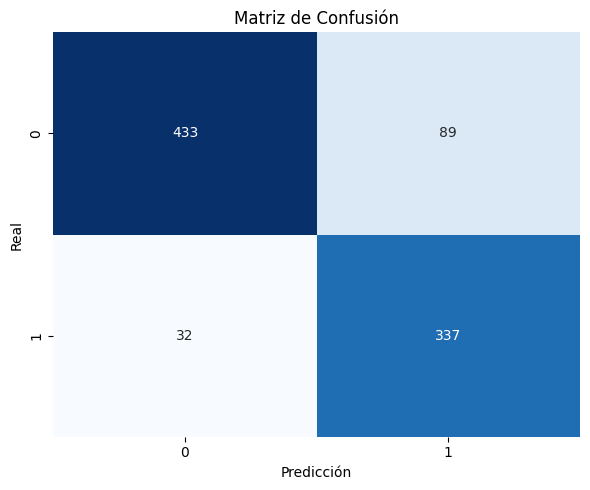

🔸 Curva ROC:


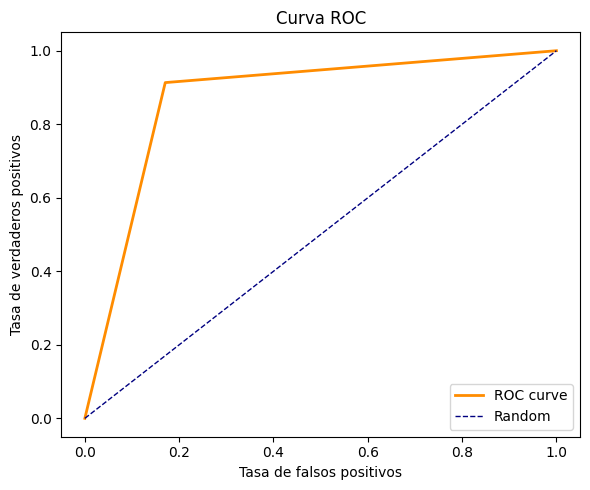

In [103]:
graficas(model_x)

In [96]:
# model LGBMClassifier
model_l = LGBMClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, verbose=-1 )
metricas(model_l)

Accuracy test:  0.7957
Accuracy train: 0.8195

AUC-ROC test:  0.7895
AUC-ROC train: 0.816


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [97]:
# model RandomForestClassifier
model_r = RandomForestClassifier(max_depth= 10, min_samples_leaf = 2, min_samples_split= 2, n_estimators= 200)
metricas(model_r)

Accuracy test:  0.8081
Accuracy train: 0.8506

AUC-ROC test:  0.804
AUC-ROC train: 0.8521


🔹 Matriz de Confusión:


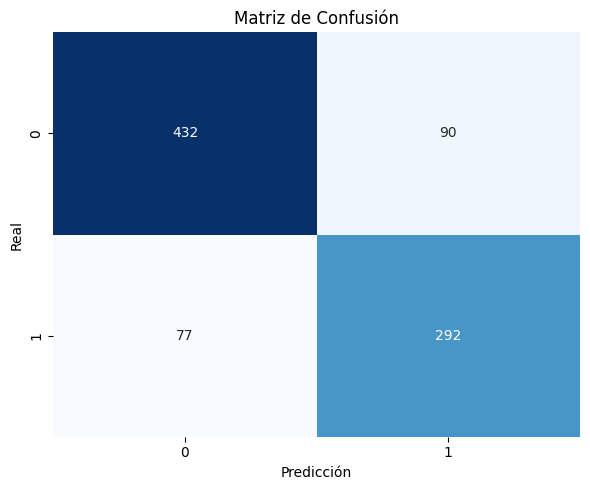

🔸 Curva ROC:


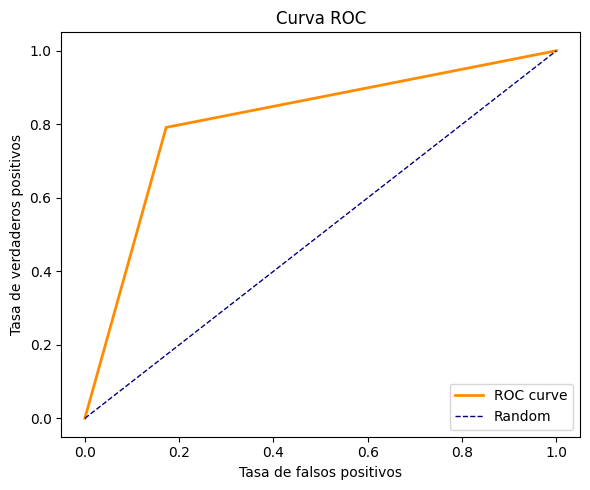

In [106]:
graficas(model_r)

In [107]:
# model RandomForest con hiperparametros
model_random_forest = RandomForestClassifier(n_estimators=300, max_depth=8, max_features="sqrt")
metricas(model_random_forest)

Accuracy test:  0.7957
Accuracy train: 0.8064

AUC-ROC test:  0.7931
AUC-ROC train: 0.8052


🔹 Matriz de Confusión:


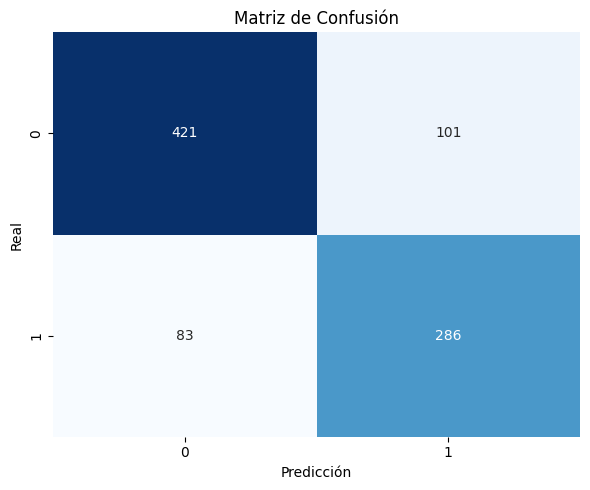

🔸 Curva ROC:


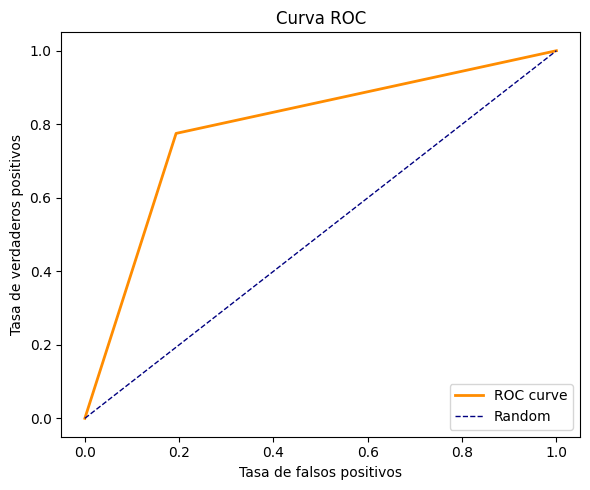

In [110]:
graficas(model_random_forest)

In [99]:
# model DecisionTreeClassifier
model_d = DecisionTreeClassifier()
metricas(model_d)

Accuracy test:  0.8945
Accuracy train: 0.9975

AUC-ROC test:  0.9072
AUC-ROC train: 0.9975


Da buenos resultados, pero está claramente sobreajustado.





🔹 Matriz de Confusión:


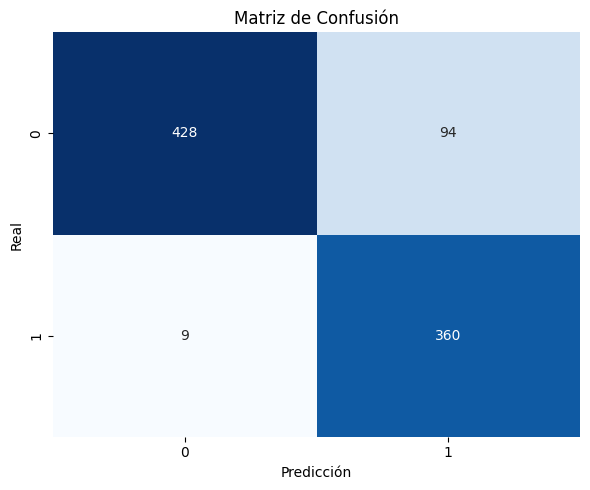

🔸 Curva ROC:


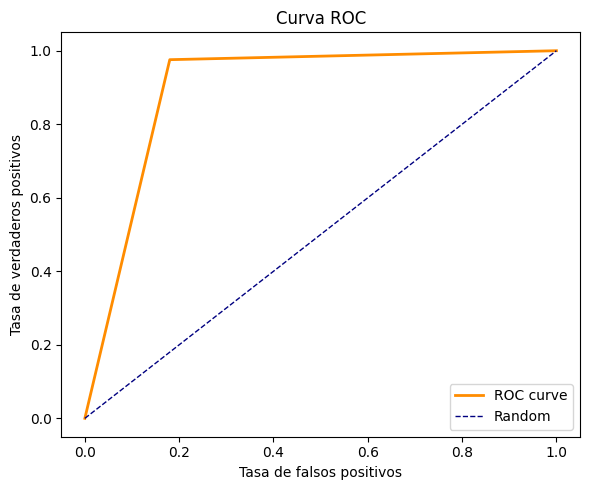

In [111]:
graficas(model_d)

In [95]:
# model CatBoost
model_c = CatBoostClassifier(random_seed=12345, depth=10, learning_rate=0.2, iterations=100, verbose=False)
metricas(model_c)

Accuracy test:  0.8732
Accuracy train: 0.9623

AUC-ROC test:  0.8806
AUC-ROC train: 0.9653


El modelo obtuvo muy buenos resultados en entrenamiento y prueba, pero la diferencia entre ambos conjuntos sugiere que podría estar sobreajustado.

🔹 Matriz de Confusión:


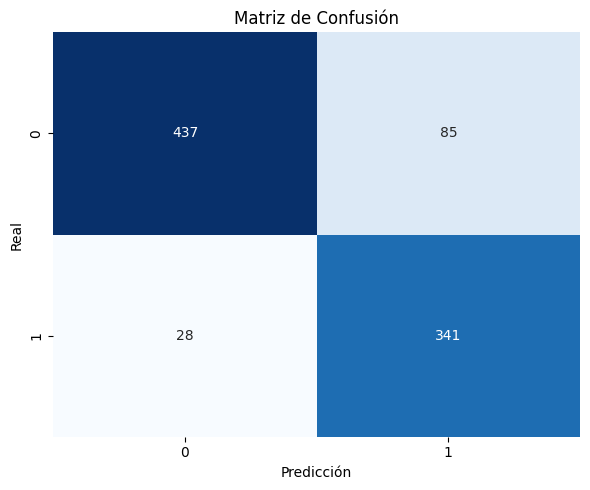

🔸 Curva ROC:


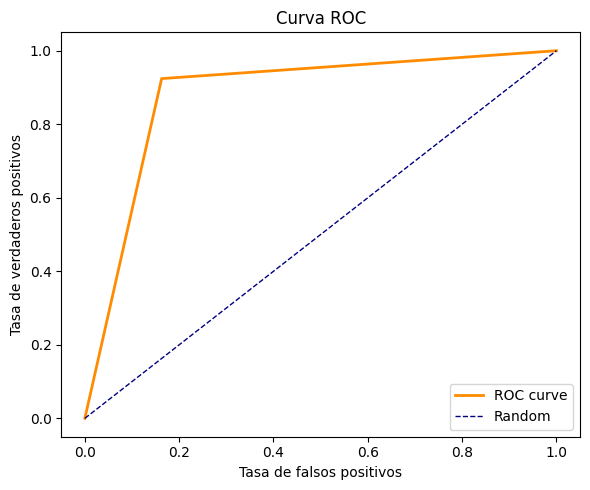

In [112]:
graficas(model_c)